## Phase 2: Data Preprocessing

### Objectives

In this notebook, we will:

- Load the cleaned dataset from Phase 1
- Encode categorical variables for model compatibility (ordinal + one-hot)
- Analyze and handle skewness in numerical features
- Apply appropriate scaling techniques
- Preprocess the test dataset using the same fitted steps
- Save model-ready datasets for Phase 3 (Feature Engineering)


In [8]:
# Task 1: Import Libraries and Load Cleaned Data

# TODO: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)

# TODO: Set pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported and display options set successfully.")

# TODO: Load cleaned data from Phase 1
# - Read 'train_cleaned.csv' using pd.read_csv()
# - Store in variable 'df'
df = pd.read_csv("train_cleaned.csv")

# TODO: Print dataset information
print("Dataset shape:", df.shape)
print("Total missing values:", int(df.isnull().sum().sum()))
df.head()

Libraries imported and display options set successfully.
Dataset shape: (1458, 77)
Total missing values: 2073


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


### Task 2: Separate Features and Target

Separate the target variable (`SalePrice`) from the features for preprocessing.


In [9]:
# TODO: Separate target variable from features
# - Create 'y' = copy of 'SalePrice' column
# - Create 'X' = dataframe without 'SalePrice'

y = df["SalePrice"].copy()
X = df.drop(columns=["SalePrice"]).copy()

# TODO: Drop 'Id' column from X if it exists (not useful for modeling)
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

# TODO: Print information
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)
print("Target statistics:")
display(y.describe())

Features shape (X): (1458, 75)
Target shape (y): (1458,)
Target statistics:


count      1458.000000
mean     180932.919067
std       79495.055285
min       34900.000000
25%      129925.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Task 3: Identify Feature Types for Encoding

Categorize features and determine appropriate encoding strategies.


In [10]:
# TODO: Identify feature types
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# TODO: Print lists with counts
print(f"Categorical features ({len(categorical_features)}):")
print(categorical_features)
print()
print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)

# TODO: Analyze categorical features cardinality
print("Categorical features cardinality:")
for col in categorical_features:
    unique_count = X[col].nunique()
    print(f"{col}: {unique_count} unique values")



Categorical features (39):
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

Numerical features (36):
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF

### Task 4: Encode Categorical Variables

We will:

- Identify **ordinal** categorical features (natural order) and encode them using mappings
- One-hot encode the remaining **nominal** categorical features


In [11]:
# Step 4.1: Identify Ordinal vs Nominal Features

# Common ordinal scales from data_description.txt
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

bsmt_exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}

bsmt_fin_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6,
}

functional_map = {
    "Sal": 0,
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7,
}

garage_finish_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}

paved_drive_map = {"N": 0, "P": 1, "Y": 2}

lot_shape_map = {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}

land_slope_map = {"Sev": 0, "Mod": 1, "Gtl": 2}

utilities_map = {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3}

street_map = {"Grvl": 0, "Pave": 1}

central_air_map = {"N": 0, "Y": 1}

# TODO: Create ordinal_mappings dictionary
ordinal_mappings = {
    # Quality ratings
    "ExterQual": quality_map,
    "ExterCond": quality_map,
    "BsmtQual": quality_map,
    "BsmtCond": quality_map,
    "HeatingQC": quality_map,
    "KitchenQual": quality_map,
    "FireplaceQu": quality_map,
    "GarageQual": quality_map,
    "GarageCond": quality_map,
    
    # Other ordinals
    "BsmtExposure": bsmt_exposure_map,
    "BsmtFinType1": bsmt_fin_map,
    "BsmtFinType2": bsmt_fin_map,
    "Functional": functional_map,
    "GarageFinish": garage_finish_map,
    "PavedDrive": paved_drive_map,
    "LotShape": lot_shape_map,
    "LandSlope": land_slope_map,
    "Utilities": utilities_map,
    "Street": street_map,
    "CentralAir": central_air_map,
}

# Only keep ordinal mappings that exist in X
ordinal_mappings = {k: v for k, v in ordinal_mappings.items() if k in X.columns}

ordinal_features = sorted(list(ordinal_mappings.keys()))
nominal_features = [c for c in categorical_features if c not in ordinal_features]

print(f"Ordinal features ({len(ordinal_features)}):")
print(ordinal_features)
print()
print(f"Nominal features ({len(nominal_features)}):")
print(nominal_features)

Ordinal features (20):
['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'CentralAir', 'ExterCond', 'ExterQual', 'FireplaceQu', 'Functional', 'GarageCond', 'GarageFinish', 'GarageQual', 'HeatingQC', 'KitchenQual', 'LandSlope', 'LotShape', 'PavedDrive', 'Street', 'Utilities']

Nominal features (19):
['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']


In [12]:
# Step 4.2: Apply Ordinal Encoding

X_encoded = X.copy()

for feature, mapping in ordinal_mappings.items():
    before_unique = X_encoded[feature].nunique(dropna=False)
    X_encoded[feature] = X_encoded[feature].map(mapping)

    # If any unseen/unknown categories appear, map() will create NaN.
    # We fill those with 0 (works well with our 'None' baseline).
    X_encoded[feature] = X_encoded[feature].fillna(0).astype(int)

    print(f"Encoded {feature} (unique before: {before_unique}, after: {X_encoded[feature].nunique()})")

print("\nOrdinal encoding sample:")
display(X_encoded[ordinal_features].head())

Encoded ExterQual (unique before: 4, after: 4)
Encoded ExterCond (unique before: 5, after: 5)
Encoded BsmtQual (unique before: 5, after: 5)
Encoded BsmtCond (unique before: 5, after: 5)
Encoded HeatingQC (unique before: 5, after: 5)
Encoded KitchenQual (unique before: 4, after: 4)
Encoded FireplaceQu (unique before: 6, after: 6)
Encoded GarageQual (unique before: 6, after: 6)
Encoded GarageCond (unique before: 6, after: 6)
Encoded BsmtExposure (unique before: 5, after: 5)
Encoded BsmtFinType1 (unique before: 7, after: 7)
Encoded BsmtFinType2 (unique before: 7, after: 7)
Encoded Functional (unique before: 7, after: 7)
Encoded GarageFinish (unique before: 4, after: 4)
Encoded PavedDrive (unique before: 3, after: 3)
Encoded LotShape (unique before: 4, after: 4)
Encoded LandSlope (unique before: 3, after: 3)
Encoded Utilities (unique before: 2, after: 2)
Encoded Street (unique before: 2, after: 2)
Encoded CentralAir (unique before: 2, after: 2)

Ordinal encoding sample:


,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtQual,CentralAir,ExterCond,ExterQual,FireplaceQu,Functional,GarageCond,GarageFinish,GarageQual,HeatingQC,KitchenQual,LandSlope,LotShape,PavedDrive,Street,Utilities
0,3,1,6,1,4,1,3,4,0,7,3,2,3,5,4,2,4,2,1,3
1,3,4,5,1,4,1,3,3,3,7,3,2,3,5,3,2,4,2,1,3
2,3,2,6,1,4,1,3,4,3,7,3,2,3,5,4,2,3,2,1,3
3,4,1,5,1,3,1,3,3,4,7,3,1,3,4,4,2,3,2,1,3
4,3,3,6,1,4,1,3,4,3,7,3,2,3,5,4,2,3,2,1,3


In [13]:
# Step 4.3: Apply One-Hot Encoding to Nominal Features

if len(nominal_features) > 0:
    X_encoded = pd.get_dummies(X_encoded, columns=nominal_features, drop_first=True, dtype=int)
    print("One-hot encoding applied.")
else:
    print("No nominal features to one-hot encode.")

print("Encoded features shape:", X_encoded.shape)
print("Total feature count:", X_encoded.shape[1])

print("\nSample of encoded dataset:")
display(X_encoded.head())

One-hot encoding applied.
Encoded features shape: (1458, 191)
Total feature count: 191

Sample of encoded dataset:


,MSSubClass,LotFrontage,LotArea,Street,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,1,4,3,2,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,1,856,854,0,1710,1,0,2,1,3,1,4,8,7,0,0,2003.0,2,2,548,3,3,2,0,61,0,0,0,0,0,2,2008,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,20,80.0,9600,1,4,3,2,6,8,1976,1976,0.0,3,3,4,3,4,5,978,1,0,284,1262,5,1,1262,0,0,1262,0,1,2,0,3,1,3,6,7,1,3,1976.0,2,2,460,3,3,2,298,0,0,0,0,0,0,5,2007,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,60,68.0,11250,1,3,3,2,7,5,2001,2002,162.0,4,3,4,3,2,6,486,1,0,434,920,5,1,920,866,0,1786,1,0,2,1,3,1,4,6,7,1,3,2001.0,2,2,608,3,3,2,0,42,0,0,0,0,0,9,2

### Task 5: Analyze Distribution and Skewness

We examine skewness in numerical features and visualize the target distribution.


Top 20 most skewed (non-binary) numeric features:


,Feature,Skewness
0,Utilities,-38.144471
1,MiscVal,24.434913
2,PoolArea,15.932532
3,LotArea,12.560986
4,3SsnPorch,10.286510
5,LowQualFinSF,8.995688
6,Functional,-4.903414
7,LandSlope,-4.805032
8,KitchenAbvGr,4.480268
9,BsmtFinSF2,4.247550


Highly skewed features (|skew| > 0.75): 34
['Utilities', 'MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'Functional', 'LandSlope', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'GarageYrBlt', 'BsmtCond', 'GarageCond', 'PavedDrive', 'BsmtFinType2', 'GarageQual', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage', 'WoodDeckSF', 'MSSubClass', 'ExterCond', 'BsmtQual', 'LotShape', 'BsmtExposure', 'GrLivArea', 'BsmtUnfSF', '1stFlrSF', 'ExterQual', '2ndFlrSF', 'BsmtFinSF1']


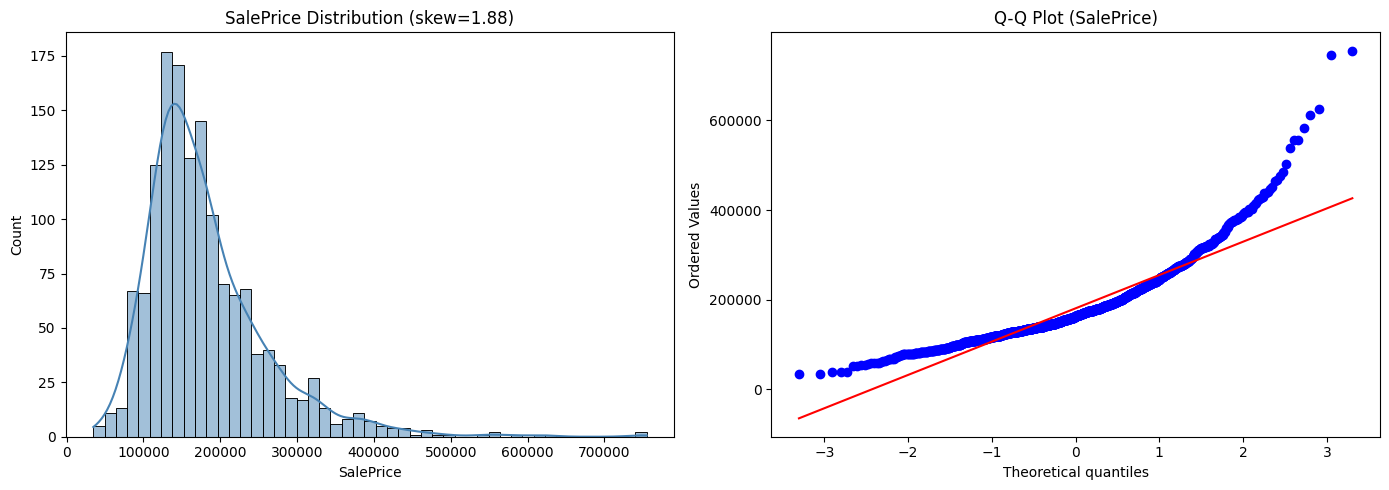

Target variable skewness: 1.8794


In [14]:
# TODO: Calculate skewness for all numerical features
num_cols_all = X_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Exclude binary dummy columns from skewness-driven transforms
binary_cols = [
    c
    for c in num_cols_all
    if X_encoded[c].dropna().isin([0, 1]).all()
]

num_cols_for_skew = [c for c in num_cols_all if c not in binary_cols]

skew_vals = X_encoded[num_cols_for_skew].apply(lambda s: stats.skew(s.dropna()))
skew_df = (
    pd.DataFrame({"Feature": skew_vals.index, "Skewness": skew_vals.values})
    .assign(AbsSkew=lambda d: d["Skewness"].abs())
    .sort_values("AbsSkew", ascending=False)
    .drop(columns=["AbsSkew"])
    .reset_index(drop=True)
)

print("Top 20 most skewed (non-binary) numeric features:")
display(skew_df.head(20))

# TODO: Identify highly skewed features
highly_skewed = skew_df.loc[skew_df["Skewness"].abs() > 0.75, "Feature"].tolist()
print(f"Highly skewed features (|skew| > 0.75): {len(highly_skewed)}")
print(highly_skewed)

# TODO: Visualize distribution of target variable
target_skew = stats.skew(y)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"SalePrice Distribution (skew={target_skew:.2f})")
axes[0].set_xlabel("SalePrice")

stats.probplot(y, plot=axes[1])
axes[1].set_title("Q-Q Plot (SalePrice)")

plt.tight_layout()
plt.show()

print(f"Target variable skewness: {target_skew:.4f}")

### Task 6: Handle Skewness

We reduce skewness using log transforms where appropriate.


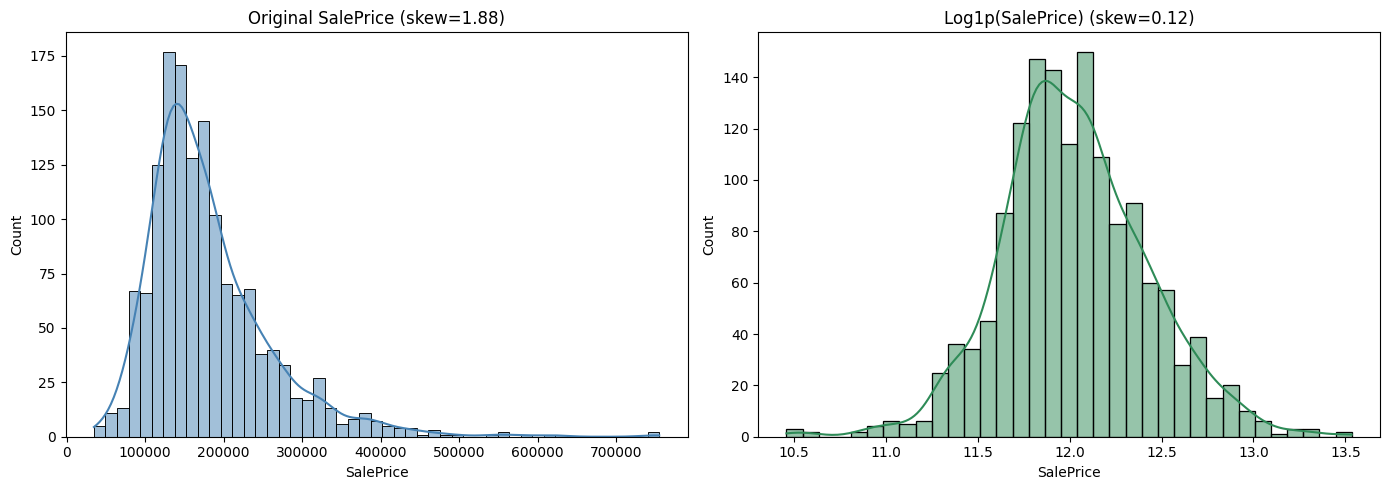

Target skewness before: 1.8794
Target skewness after : 0.1215


In [15]:
# Step 6.1: Transform Target Variable (if needed)

target_skew_before = stats.skew(y)

if abs(target_skew_before) > 0.75:
    y_transformed = np.log1p(y)
    target_skew_after = stats.skew(y_transformed)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(y, kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Original SalePrice (skew={target_skew_before:.2f})")

    sns.histplot(y_transformed, kde=True, ax=axes[1], color="seagreen")
    axes[1].set_title(f"Log1p(SalePrice) (skew={target_skew_after:.2f})")

    plt.tight_layout()
    plt.show()

    print(f"Target skewness before: {target_skew_before:.4f}")
    print(f"Target skewness after : {target_skew_after:.4f}")
else:
    y_transformed = y.copy()
    print(f"Target skewness ({target_skew_before:.4f}) within threshold; no transform applied.")

In [16]:
# Step 6.2: Transform Highly Skewed Features

X_transformed = X_encoded.copy()

skew_report = []
skipped_features = []

for feat in highly_skewed:
    if feat not in X_transformed.columns:
        continue

    col = X_transformed[feat]

    # log1p requires non-negative values
    if col.min() < 0:
        skipped_features.append(feat)
        continue

    before = stats.skew(col.dropna())
    X_transformed[feat] = np.log1p(col)
    after = stats.skew(X_transformed[feat].dropna())
    skew_report.append((feat, before, after))

print(f"Applied log1p transformation to {len(skew_report)} features.")
if skipped_features:
    print(f"Skipped {len(skipped_features)} features with negative values:")
    print(skipped_features)

# Display a compact skewness report (top 25 by before-skew magnitude)
if skew_report:
    rep = pd.DataFrame(skew_report, columns=["Feature", "Skew_Before", "Skew_After"])
    rep["Abs_Before"] = rep["Skew_Before"].abs()
    rep = rep.sort_values("Abs_Before", ascending=False).drop(columns=["Abs_Before"]).reset_index(drop=True)
    display(rep.head(25))

print("Skewness handling completed.")

Applied log1p transformation to 34 features.


,Feature,Skew_Before,Skew_After
0,Utilities,-38.144471,-38.144471
1,MiscVal,24.434913,5.161462
2,PoolArea,15.932532,15.501716
3,LotArea,12.560986,-0.181091
4,3SsnPorch,10.286510,7.721468
5,LowQualFinSF,8.995688,7.447271
6,Functional,-4.903414,-5.900091
7,LandSlope,-4.805032,-5.848928
8,KitchenAbvGr,4.480268,3.862290
9,BsmtFinSF2,4.247550,2.518628


Skewness handling completed.


### Task 7: Feature Scaling

We scale continuous numeric features (leaving one-hot/binary indicators as 0/1).


Numeric features to scale (non-binary): 54
Scaler used: StandardScaler
Scaled feature summary (mean/std of first 5 scaled features):


,mean,std
MSSubClass,-1.589949e-16,1.0
LotFrontage,1.201295e-15,1.0
LotArea,-1.386484e-15,1.0
LotShape,5.019609e-16,1.0
Utilities,-7.775521e-15,1.0


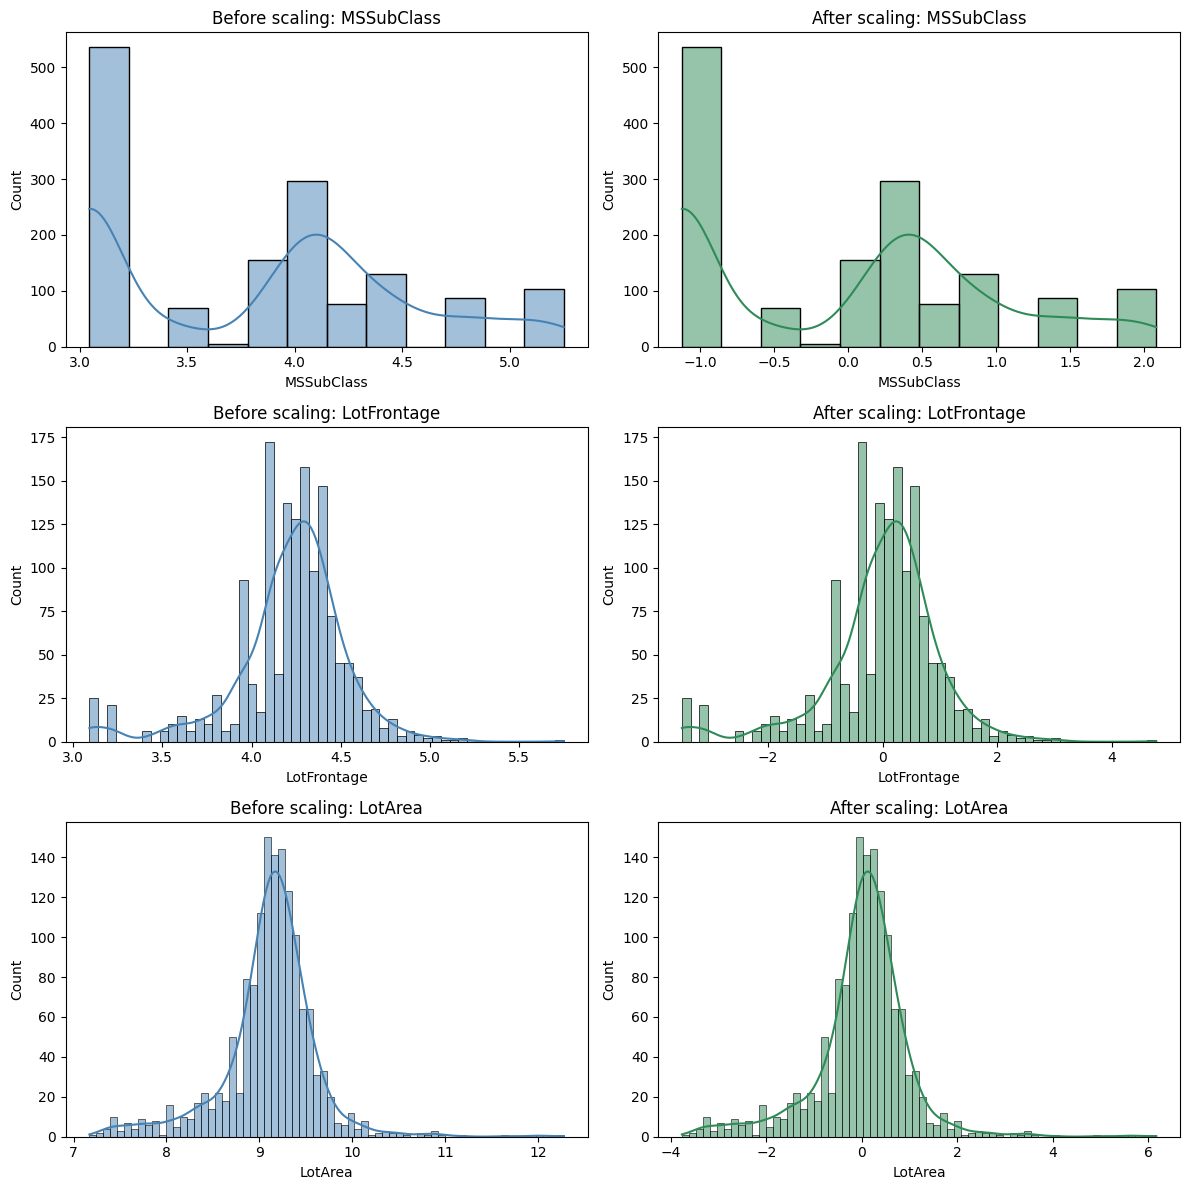

In [17]:
# TODO: Get numerical columns after transformation
num_cols_transformed = X_transformed.select_dtypes(include=[np.number]).columns.tolist()

binary_cols_transformed = [
    c
    for c in num_cols_transformed
    if X_transformed[c].dropna().isin([0, 1]).all()
]

numeric_features_to_scale = [c for c in num_cols_transformed if c not in binary_cols_transformed]

print(f"Numeric features to scale (non-binary): {len(numeric_features_to_scale)}")

# Step 7.1: Choose and Apply Scaling Method
X_scaled = X_transformed.copy()

scaler = StandardScaler()  # recommended after log transform
X_scaled[numeric_features_to_scale] = scaler.fit_transform(X_scaled[numeric_features_to_scale])

print(f"Scaler used: {scaler.__class__.__name__}")
print("Scaled feature summary (mean/std of first 5 scaled features):")
scaled_summary = pd.DataFrame(
    {
        "mean": X_scaled[numeric_features_to_scale].mean().head(5),
        "std": X_scaled[numeric_features_to_scale].std(ddof=0).head(5),
    }
)
display(scaled_summary)

# TODO: Visualize effect of scaling
sample_features = numeric_features_to_scale[:3]

if len(sample_features) > 0:
    fig, axes = plt.subplots(len(sample_features), 2, figsize=(12, 4 * len(sample_features)))
    if len(sample_features) == 1:
        axes = np.array([axes])

    for i, feat in enumerate(sample_features):
        sns.histplot(X_transformed[feat], kde=True, ax=axes[i, 0], color="steelblue")
        axes[i, 0].set_title(f"Before scaling: {feat}")

        sns.histplot(X_scaled[feat], kde=True, ax=axes[i, 1], color="seagreen")
        axes[i, 1].set_title(f"After scaling: {feat}")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric features selected for scaling.")

### Task 8: Process Test Dataset

We apply the same cleaning (Phase 1), encoding, transformations, and scaling to the test set using **training-fitted** parameters (mappings, columns, scaler).


In [18]:
# TODO: Load test dataset

test_df = pd.read_csv("test.csv")
print("Test shape:", test_df.shape)
print("Test missing values:", int(test_df.isnull().sum().sum()))

# TODO: Save test IDs for later submission
if "Id" in test_df.columns:
    test_ids = test_df["Id"].copy()
else:
    test_ids = pd.Series(np.arange(len(test_df)), name="Id")

# TODO: Drop 'Id' column from test_df
if "Id" in test_df.columns:
    test_df = test_df.drop(columns=["Id"])

Test shape: (1459, 80)
Test missing values: 7878


In [19]:
# Step 8.1: Apply Same Cleaning and Encoding to Test Data

# ---- Phase 1 cleaning replicated (using training-derived stats where appropriate) ----

from pandas.api.types import is_numeric_dtype

def clean_like_phase1(df_raw: pd.DataFrame, train_ref: pd.DataFrame) -> pd.DataFrame:
    df_clean = df_raw.copy()

    # Same sparse drops used in Phase 1
    features_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]
    features_to_drop = [c for c in features_to_drop if c in df_clean.columns]
    if features_to_drop:
        df_clean = df_clean.drop(columns=features_to_drop)

    # Missing-by-design categorical fills
    none_fill_cols = [
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
        "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "MasVnrType",
    ]
    none_fill_cols = [c for c in none_fill_cols if c in df_clean.columns]
    for c in none_fill_cols:
        df_clean[c] = df_clean[c].fillna("None")

    # LotFrontage: Neighborhood median (use training neighborhood medians, fallback to training global median)
    if "LotFrontage" in df_clean.columns and "Neighborhood" in df_clean.columns:
        neigh_median = train_ref.groupby("Neighborhood")["LotFrontage"].median()
        global_median = float(train_ref["LotFrontage"].median())
        missing_mask = df_clean["LotFrontage"].isnull()
        if missing_mask.any():
            df_clean.loc[missing_mask, "LotFrontage"] = (
                df_clean.loc[missing_mask, "Neighborhood"].map(neigh_median)
            )
            df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(global_median)

    # MasVnrArea / GarageYrBlt
    if "MasVnrArea" in df_clean.columns:
        df_clean["MasVnrArea"] = df_clean["MasVnrArea"].fillna(0)
    if "GarageYrBlt" in df_clean.columns:
        df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(0)

    # FIX: Use select_dtypes instead of dtype == "object" (pandas version-safe)
    train_cat_cols = train_ref.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    cat_cols = df_clean.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    for c in cat_cols:
        if df_clean[c].isnull().any():
            if c in train_cat_cols:
                df_clean[c] = df_clean[c].fillna(train_ref[c].mode(dropna=True)[0])
            else:
                df_clean[c] = df_clean[c].fillna(df_clean[c].mode(dropna=True)[0])

    # Remaining numeric missing → training median
    train_num_cols = [c for c in train_ref.columns if is_numeric_dtype(train_ref[c])]
    num_cols = [c for c in df_clean.columns if is_numeric_dtype(df_clean[c])]
    for c in num_cols:
        if df_clean[c].isnull().any():
            if c in train_num_cols:
                df_clean[c] = df_clean[c].fillna(train_ref[c].median())
            else:
                df_clean[c] = df_clean[c].fillna(df_clean[c].median())

    return df_clean

# Clean test
train_ref_for_cleaning = df.drop(columns=["SalePrice"]).copy()
if "Id" in train_ref_for_cleaning.columns:
    train_ref_for_cleaning = train_ref_for_cleaning.drop(columns=["Id"])

test_cleaned = clean_like_phase1(test_df, train_ref_for_cleaning)

# Align cleaned test columns to training feature columns
missing_in_test = [c for c in X.columns if c not in test_cleaned.columns]
extra_in_test = [c for c in test_cleaned.columns if c not in X.columns]

if extra_in_test:
    test_cleaned = test_cleaned.drop(columns=extra_in_test)

for c in missing_in_test:
    if c in categorical_features:
        test_cleaned[c] = "None"
    else:
        test_cleaned[c] = 0

test_cleaned = test_cleaned[X.columns]

print("Cleaned test shape (aligned):", test_cleaned.shape)
print("Cleaned test missing values:", int(test_cleaned.isnull().sum().sum()))

# ---- Encoding using training-defined feature groups/mappings ----

# FIX: test_encoded əvvəlcə test_cleaned-dən yaradılır, sonra encode edilir
test_encoded = test_cleaned.copy()

for feature, mapping in ordinal_mappings.items():
    if feature in test_encoded.columns:
        test_encoded[feature] = test_encoded[feature].map(mapping)
        test_encoded[feature] = test_encoded[feature].fillna(0).astype(int)

nominal_cols_present = [c for c in nominal_features if c in test_encoded.columns]
if nominal_cols_present:
    test_encoded = pd.get_dummies(test_encoded, columns=nominal_cols_present, drop_first=True, dtype=int)

# Align one-hot columns to training encoded columns
test_encoded = test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

print("Test encoded shape:", test_encoded.shape)

# ---- Apply same log transforms as training ----
log_features_applied = [feat for feat, _, _ in skew_report]

test_transformed = test_encoded.copy()
for feat in log_features_applied:
    if feat in test_transformed.columns:
        if test_transformed[feat].min() >= 0:
            test_transformed[feat] = np.log1p(test_transformed[feat])

# ---- Apply same scaling (transform only) ----
test_scaled = test_transformed.copy()
test_scaled[numeric_features_to_scale] = scaler.transform(test_scaled[numeric_features_to_scale])

print("Final test preprocessed shape:", test_scaled.shape)
print("Final test missing values:", int(test_scaled.isnull().sum().sum()))


Cleaned test shape (aligned): (1459, 75)
Cleaned test missing values: 0
Test encoded shape: (1459, 191)
Final test preprocessed shape: (1459, 191)
Final test missing values: 0


### Task 9: Final Verification and Save

We verify preprocessing outputs and save the final datasets.


In [20]:
# Final verification

print("=== Training set (X_scaled) ===")
print("Shape:", X_scaled.shape)
print("Missing values:", int(X_scaled.isnull().sum().sum()))
print("Dtype counts:")
print(X_scaled.dtypes.value_counts())

print("\n=== Target (y_transformed) ===")
print("Shape:", y_transformed.shape)
print("Range:", float(y_transformed.min()), "to", float(y_transformed.max()))
print("Skewness:", float(stats.skew(y_transformed)))

# Verify all features are numeric
obj_cols_train = X_scaled.select_dtypes(include=["object"]).columns.tolist()
print("\nNon-numeric (object) columns remaining in training:", obj_cols_train)

print("\n=== Test set (test_scaled) ===")
print("Shape:", test_scaled.shape)
print("Missing values:", int(test_scaled.isnull().sum().sum()))
obj_cols_test = test_scaled.select_dtypes(include=["object"]).columns.tolist()
print("Non-numeric (object) columns remaining in test:", obj_cols_test)

# Save preprocessed datasets
X_scaled.to_csv("train_preprocessed.csv", index=False)
pd.DataFrame({"SalePrice": y_transformed}).to_csv("train_target.csv", index=False)

test_scaled.to_csv("test_preprocessed.csv", index=False)
pd.DataFrame({"Id": test_ids}).to_csv("test_ids.csv", index=False)

print("\nSaved files:")
print("- train_preprocessed.csv")
print("- train_target.csv")
print("- test_preprocessed.csv")
print("- test_ids.csv")


=== Training set (X_scaled) ===
Shape: (1458, 191)
Missing values: 0
Dtype counts:
int64      137
float64     54
Name: count, dtype: int64

=== Target (y_transformed) ===
Shape: (1458,)
Range: 10.460270761075149 to 13.534474352733596
Skewness: 0.12145464268184525

Non-numeric (object) columns remaining in training: []

=== Test set (test_scaled) ===
Shape: (1459, 191)
Missing values: 0
Non-numeric (object) columns remaining in test: []

Saved files:
- train_preprocessed.csv
- train_target.csv
- test_preprocessed.csv
- test_ids.csv
